# Q4 - Otsu Thresholding and Foreground Equalization

This notebook converts the image to grayscale, uses Otsu thresholding to obtain the foreground mask, and applies histogram equalization only to the foreground region.

## 1 — Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 2 — Set Input and Output Paths

In [2]:
img_path = Path("../data/raw/woman_window.jpg")   # change if your filename is different
out_dir = Path("../results/q04")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())


Input path: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\woman_window.jpg
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q04


## 3 — Load Image and Convert to Grayscale

In [3]:
img_bgr = cv2.imread(str(img_path))

if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Image loaded successfully")
print("Shape:", gray.shape)
print("Data type:", gray.dtype)


Image loaded successfully
Shape: (5867, 4693)
Data type: uint8


## 4 — Display Grayscale Image

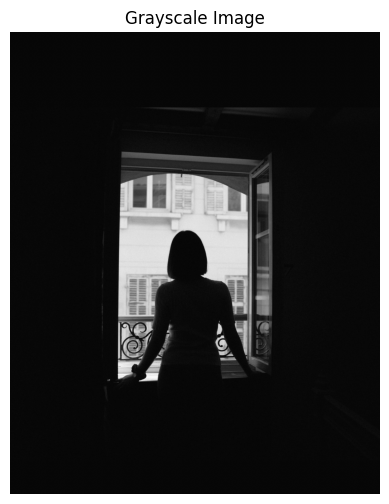

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


## 5 — Apply Otsu Thresholding

In [5]:
otsu_thresh, mask = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

mean_fg = gray[mask == 255].mean() if np.any(mask == 255) else 255
mean_bg = gray[mask == 0].mean() if np.any(mask == 0) else 0

if mean_fg > mean_bg:
    mask = cv2.bitwise_not(mask)

print(f"Otsu threshold value: {otsu_thresh:.2f}")


Otsu threshold value: 101.00


## 6 — Display Foreground Mask

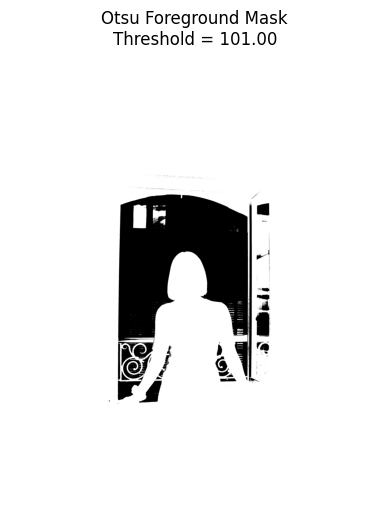

In [6]:
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title(f"Otsu Foreground Mask\nThreshold = {otsu_thresh:.2f}")
plt.axis("off")
plt.show()


## 7 — Define Foreground-Only Histogram Equalization Function

In [7]:
def equalize_foreground_only(gray, mask):
    result = gray.copy()

    fg_pixels = gray[mask == 255]

    if fg_pixels.size == 0:
        return result

    hist = np.bincount(fg_pixels, minlength=256)
    cdf = hist.cumsum()
    nonzero = np.nonzero(cdf)[0]

    if len(nonzero) == 0:
        return result

    cdf_min = cdf[nonzero[0]]
    total_fg = fg_pixels.size

    if total_fg == cdf_min:
        return result

    lut = np.round((cdf - cdf_min) / (total_fg - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    result[mask == 255] = lut[gray[mask == 255]]
    return result


## 8 — Apply Histogram Equalization to Foreground

In [8]:
eq_foreground = equalize_foreground_only(gray, mask)
print("Foreground equalization completed.")


Foreground equalization completed.


## 9 — Display Grayscale, Mask, and Equalized Result

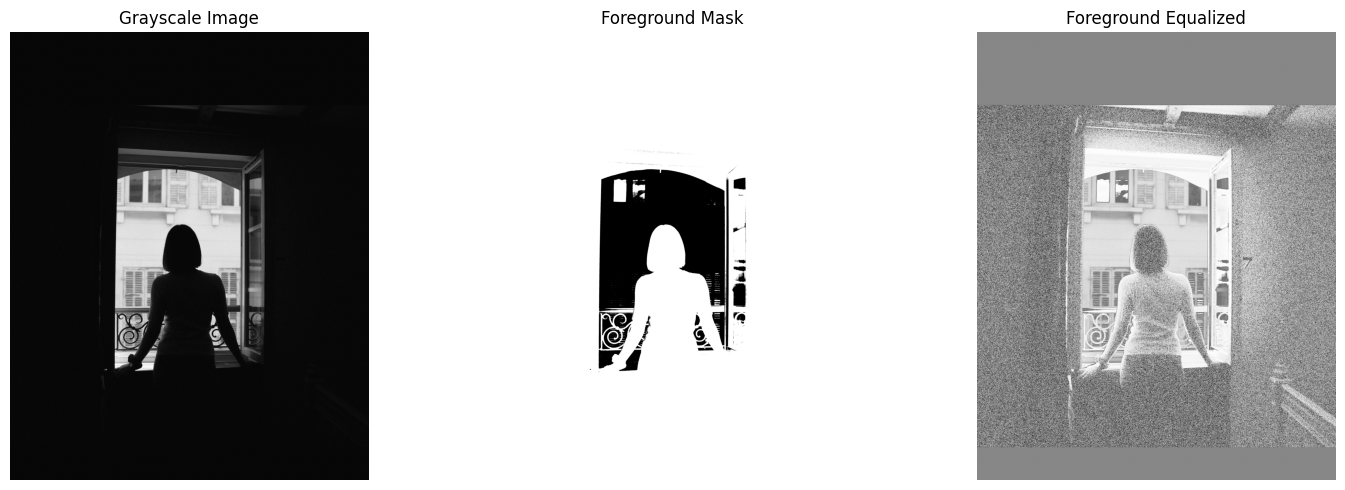

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(eq_foreground, cmap="gray")
plt.title("Foreground Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()


## 10 — Save Output Images

In [10]:
cv2.imwrite(str(out_dir / "q04_gray.png"), gray)
cv2.imwrite(str(out_dir / "q04_otsu_mask.png"), mask)
cv2.imwrite(str(out_dir / "q04_foreground_equalized.png"), eq_foreground)

print(f"Saved grayscale image to: {out_dir / 'q04_gray.png'}")
print(f"Saved mask to: {out_dir / 'q04_otsu_mask.png'}")
print(f"Saved equalized result to: {out_dir / 'q04_foreground_equalized.png'}")


Saved grayscale image to: ..\results\q04\q04_gray.png
Saved mask to: ..\results\q04\q04_otsu_mask.png
Saved equalized result to: ..\results\q04\q04_foreground_equalized.png


## 11 — Plot Foreground Histograms

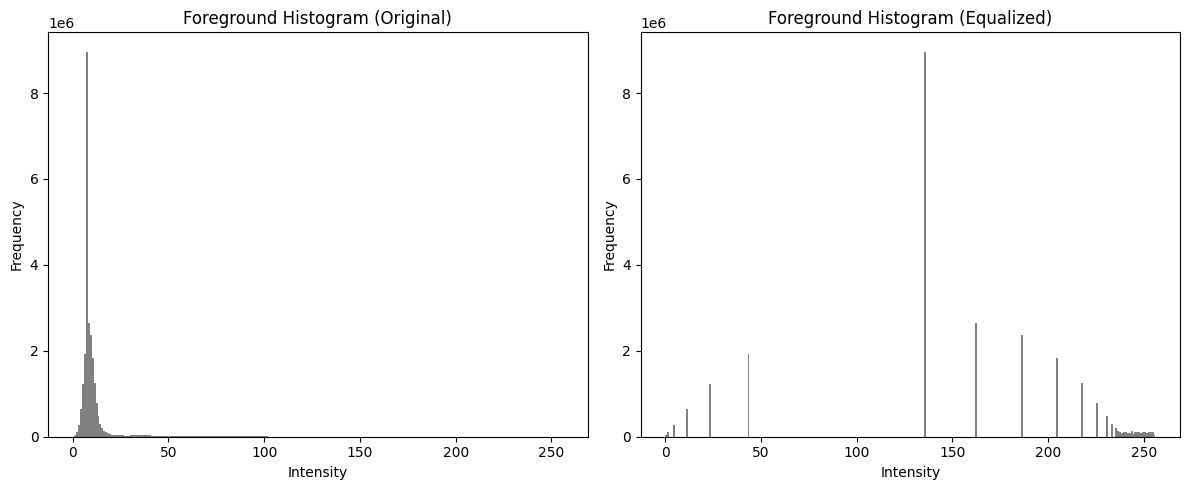

In [11]:
fg_original = gray[mask == 255]
fg_equalized = eq_foreground[mask == 255]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(fg_original, bins=256, range=[0, 256], color="gray")
plt.title("Foreground Histogram (Original)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(fg_equalized, bins=256, range=[0, 256], color="gray")
plt.title("Foreground Histogram (Equalized)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## Otsu Thresholding and Foreground Equalization

The image was first converted to grayscale. Otsu thresholding was then applied to separate the dark foreground region from the bright background. The foreground was defined as the woman and the room interior.

Next, histogram equalization was applied only to the foreground pixels. This improved the contrast of the dark indoor region without significantly changing the bright outside area.

The resulting image reveals clearer silhouette boundaries and additional hidden details in the room.